In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds, get_normalized_ds
from src.visualizations.umap_visualizer import UMAPLatent

/Users/bhaveshkalisetti/anaconda3/envs/venv/lib/python3.11/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bhaveshkalisetti/anaconda3/envs/venv/lib/python3.11/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bhaveshkalisetti/anaconda3/envs/venv/lib/pyth

In [2]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.linalg.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.linalg.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(2 * hidden_dim, latent_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, (hidden, cell) = self.lstm1(x)
        x = self.dropout(x)
        x, (hidden, cell) = self.lstm2(x)
        return x, hidden[-1, :, :]

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.lstm1 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_dim, output_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        return x

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, output_dim)
        
    def forward(self, x):
        x, embeddings = self.encoder(x)
        x = self.decoder(x)
        return x, embeddings

In [5]:
class AutoencoderTrainer(nn.Module):
    def __init__(self, models, train_ds, test_ds, num_variables, index_to_class, batch_size, lr1, lr2, epochs1, epochs2):
        super(AutoencoderTrainer, self).__init__()
        self.models = models
        self.train_ds = train_ds   
        self.test_ds = test_ds
        self.num_variables = num_variables
        self.index_to_class = index_to_class
        self.batch_size = batch_size
        self.lr1 = lr1
        self.lr2 = lr2
        self.epochs1 = epochs1
        self.epochs2 = epochs2

        self.train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        self.test_dataloader = DataLoader(test_ds, len(test_ds), shuffle=False)

        self.contrastive_opts = [torch.optim.Adam(self.models[i].encoder.parameters(), lr=lr1) for i in range(num_variables)]
        self.reconstruction_opts = [torch.optim.Adam(self.models[i].decoder.parameters(), lr=lr2) for i in range(num_variables)]

        self.contrastive_scheds = [torch.optim.lr_scheduler.ExponentialLR(self.contrastive_opts[i], 0.999) for i in range(num_variables)]
        self.reconstruction_scheds = [torch.optim.lr_scheduler.ExponentialLR(self.reconstruction_opts[i], 0.999) for i in range(num_variables)]
        
        self.contrastive_loss_fn = SiameseContrastiveLoss(m=1.0)
        self.reconstruction_loss_fn = nn.MSELoss()

        self.reconstruction_losses = [[] for _ in range(num_variables)]
        self.contrastive_losses = [[] for _ in range(num_variables)]

    def train(self):
        for model in self.models:
            model.train()
        for epoch in tqdm(range(self.epochs1)):
            for i in range(self.num_variables):
                for batch_idx, (data, labels) in enumerate(self.train_dataloader):
                    data = data[:, :, i].unsqueeze(2).float()
                    self.contrastive_opts[i].zero_grad()
                    output, embeddings = self.models[i](data)
                    reconstruction_loss = self.reconstruction_loss_fn(output, data)
                    contrastive_loss = self.contrastive_loss_fn(embeddings, labels)
                    contrastive_loss.backward()
                    self.contrastive_opts[i].step()
                self.contrastive_scheds[i].step()
                self.contrastive_losses[i].append(contrastive_loss.item())

        for epoch in tqdm(range(self.epochs2)):
            for i in range(self.num_variables):
                for batch_idx, (data, labels) in enumerate(self.train_dataloader):
                    data = data[:, :, i].unsqueeze(2).float()
                    self.reconstruction_opts[i].zero_grad()
                    output, embeddings = self.models[i](data)
                    reconstruction_loss = self.reconstruction_loss_fn(output, data)
                    reconstruction_loss.backward()
                    self.reconstruction_opts[i].step()
                self.reconstruction_scheds[i].step()
                self.reconstruction_losses[i].append(reconstruction_loss.item())

    def plot_contrastive_losses(self, variable=None):
        plt.figure()
        plt.title("Contrastive Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.contrastive_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.contrastive_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_reconstruction_losses(self, variable=None):
        plt.figure()
        plt.title("Reconstruction Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.reconstruction_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.reconstruction_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_latent_spaces(self):
        for data_matrix, labels in self.test_dataloader:
            for i in range(self.num_variables):
                plt.figure()
                inp = data_matrix[:, :, i].unsqueeze(2).float()
                with torch.no_grad():
                    _, embeddings = self.models[i](inp)

                    reducer = umap.UMAP()
                    embeddings_2d = reducer.fit_transform(embeddings)

                    string_labels = np.array([self.index_to_class[float(label)] for label in labels])
                    unique_labels = ["Standing", "Walking", "Running", "Badminton"]

                    handles, lbls = [], []
                    for label in unique_labels:
                        idx = np.where(string_labels == label)[0]
                        scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                        handles.append(scatter)
                        lbls.append(label)
                        
                    plt.legend(handles, lbls)
                    plt.title("Latent Space for Variable " + str(i + 1))
                    plt.show()

    def plot_basicmotions_reconstructions(self, variable):
        for model in self.models:
            model.eval()
        for data_matrix, labels in self.test_dataloader:
            inp = data_matrix[:, :, variable].unsqueeze(2).float()
            with torch.no_grad():
                output, _ = self.models[variable](inp)
                plt.figure()
                index = random.randint(0, 9)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Standing")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(10, 19)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Running")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(20, 29)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Walking")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(30, 39)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]


                plt.title("Badminton")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.show()

    

In [6]:
# Load in BasicMotions dataset
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}
index_to_class = {0:"Standing", 1:"Running", 2:"Walking", 3:"Badminton", 4:"Prototype"}

train_ds, test_ds = get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [7]:
autoencoders = torch.nn.ModuleList([Autoencoder(input_dim=1, hidden_dim=128, latent_dim=32, output_dim=1) for _ in range(6)])
autoencoder_trainer = AutoencoderTrainer(
    models=autoencoders,
    train_ds=train_ds,
    test_ds=test_ds,
    num_variables=6,
    index_to_class=index_to_class,
    batch_size=40,
    lr1=0.01,
    lr2=0.01,
    epochs1=1000,
    epochs2=1000,
)

In [8]:
autoencoder_trainer.train()

100%|██████████| 1000/1000 [15:53<00:00,  1.05it/s]


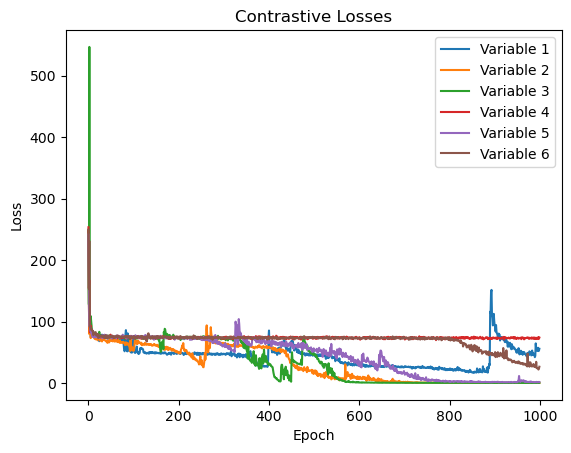

In [9]:
autoencoder_trainer.plot_contrastive_losses()

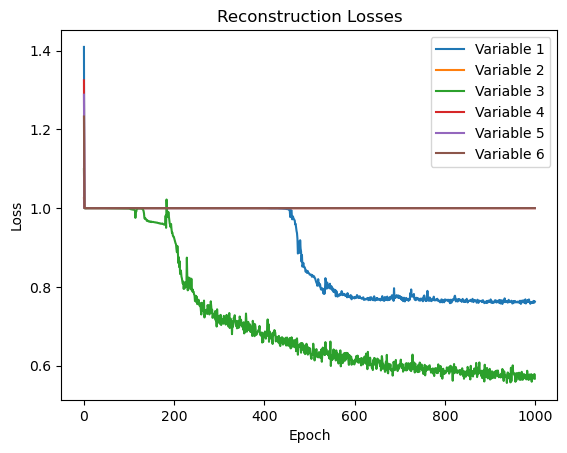

In [10]:
autoencoder_trainer.plot_reconstruction_losses()

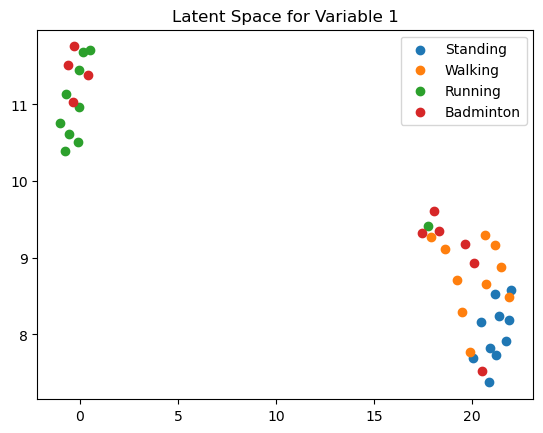

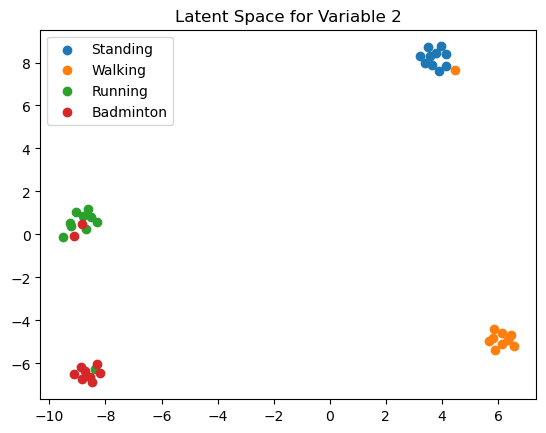

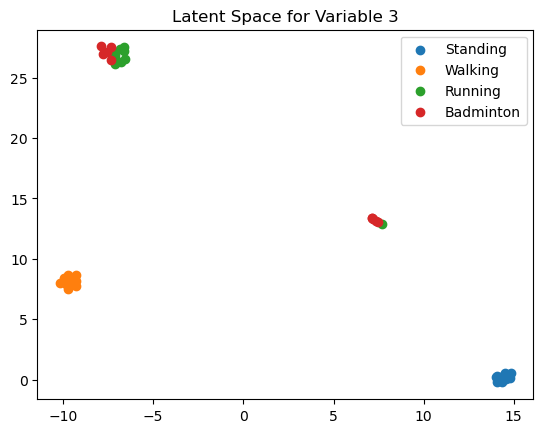

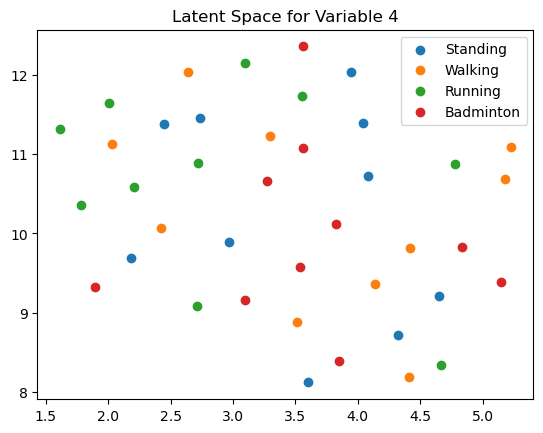

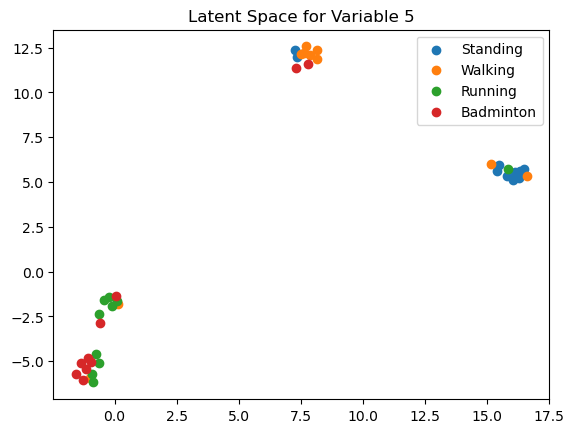

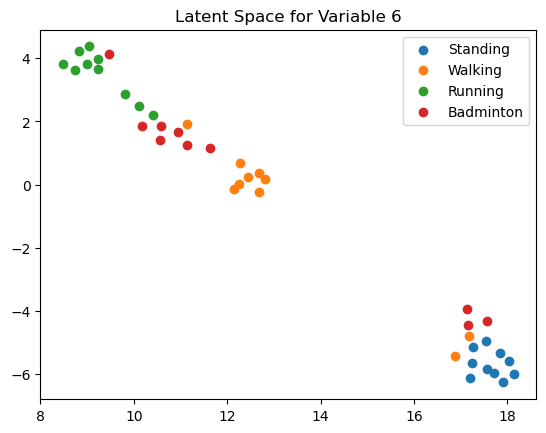

In [11]:
autoencoder_trainer.plot_latent_spaces()

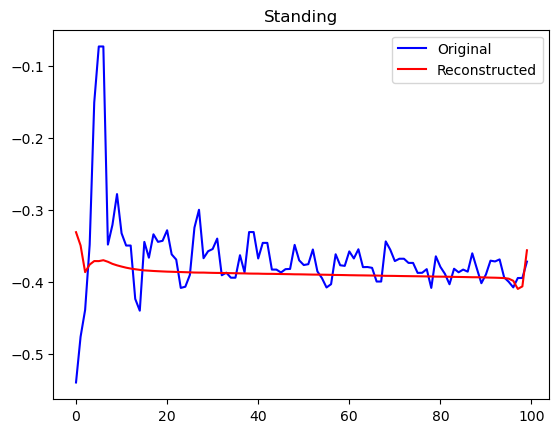

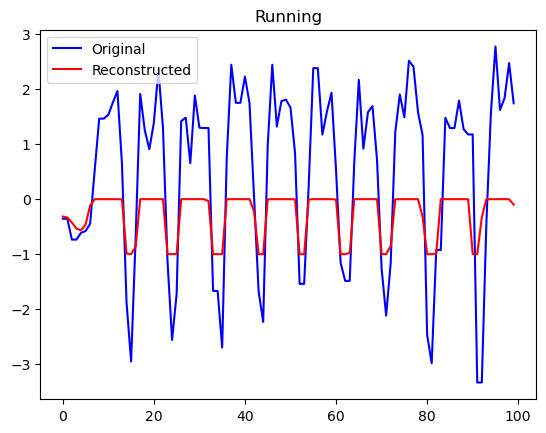

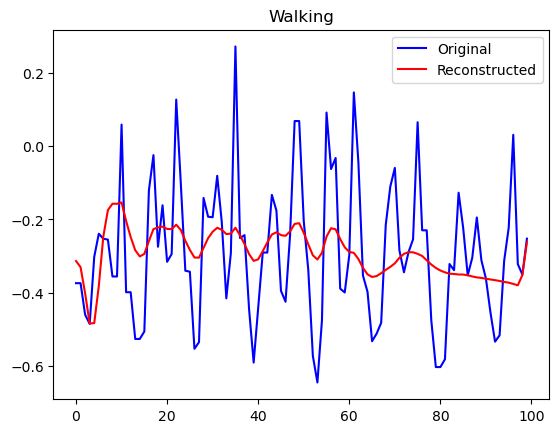

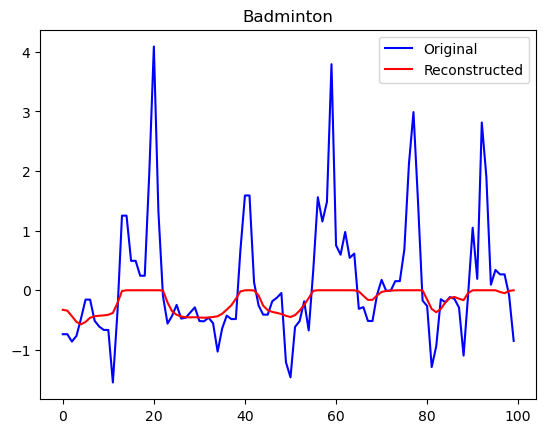

In [12]:
autoencoder_trainer.plot_basicmotions_reconstructions(variable=0)

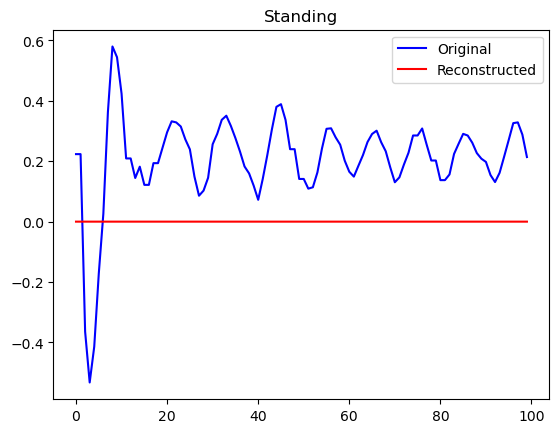

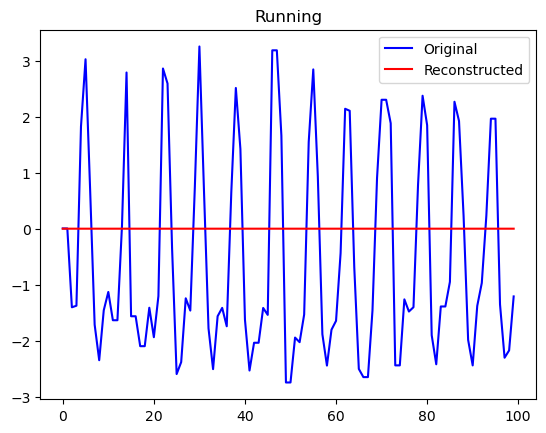

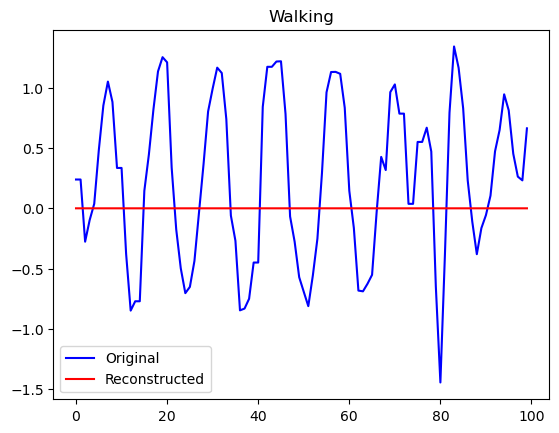

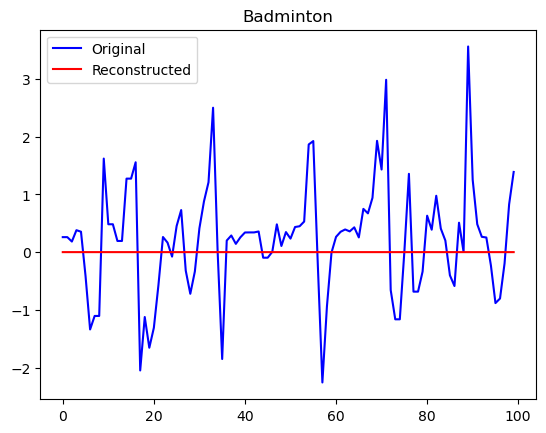

In [13]:
autoencoder_trainer.plot_basicmotions_reconstructions(variable=1)

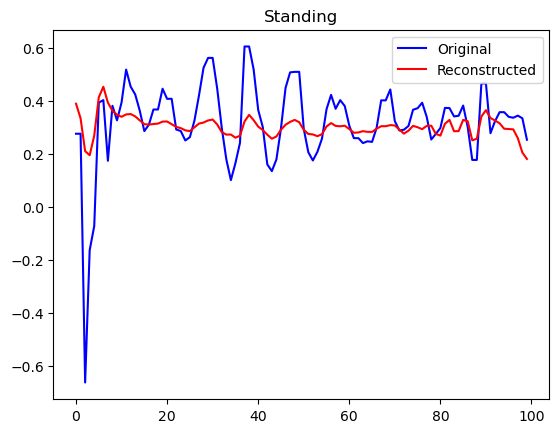

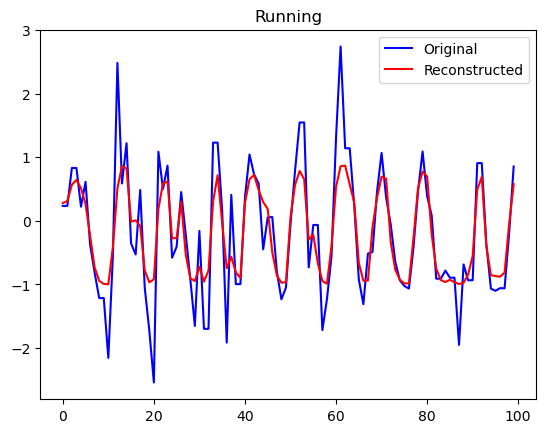

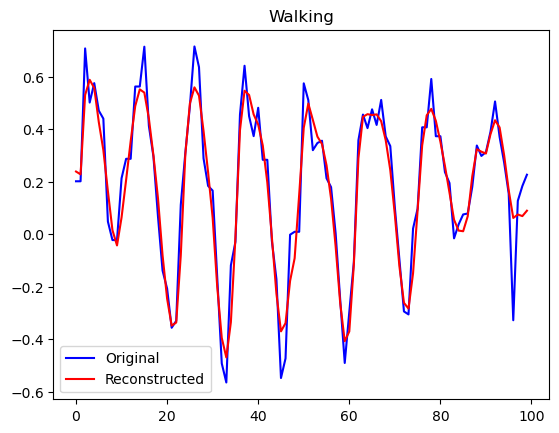

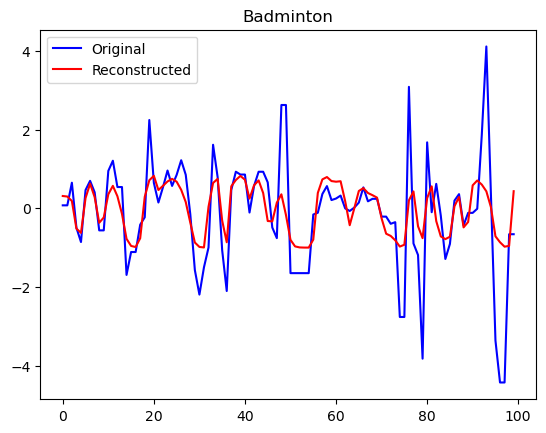

In [14]:
autoencoder_trainer.plot_basicmotions_reconstructions(variable=2)

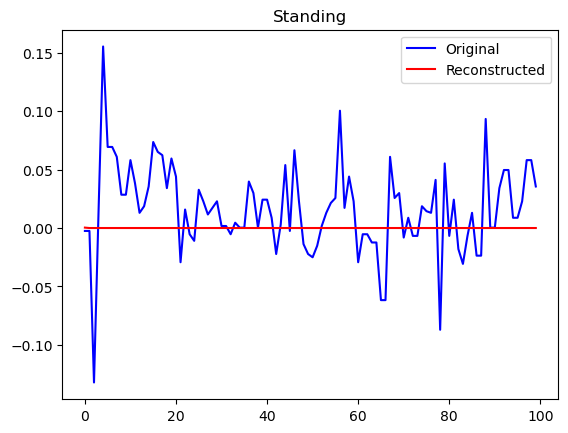

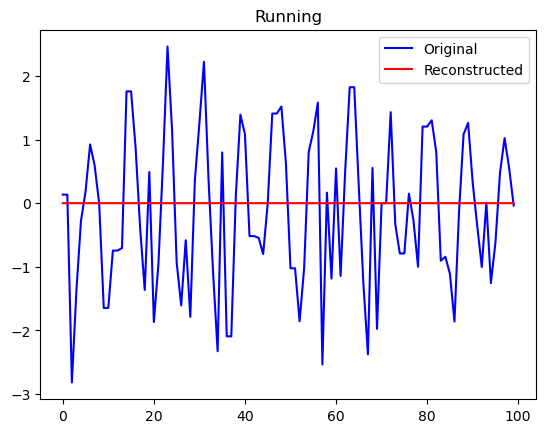

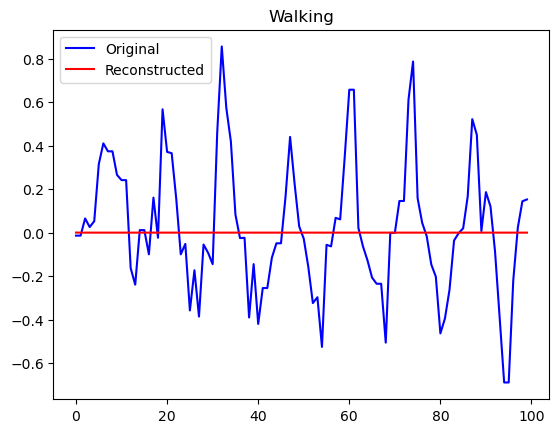

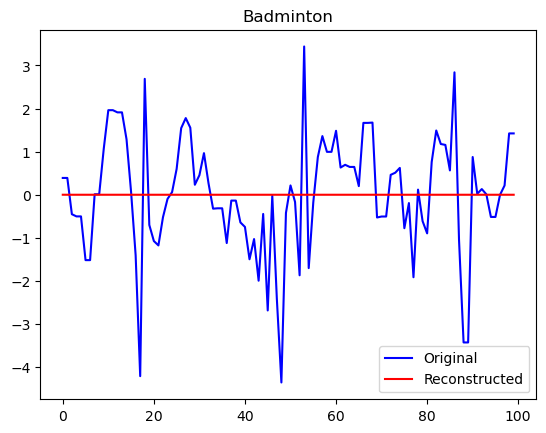

In [15]:
autoencoder_trainer.plot_basicmotions_reconstructions(variable=3)

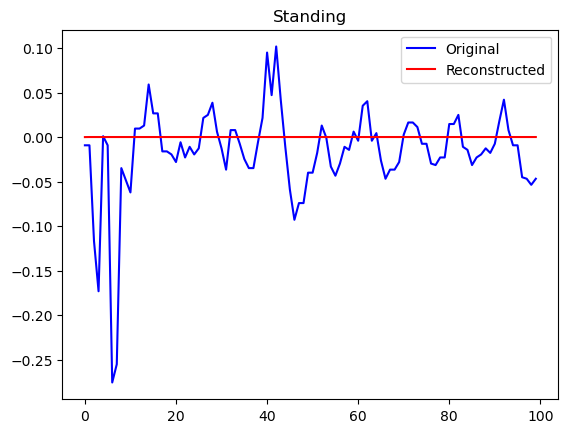

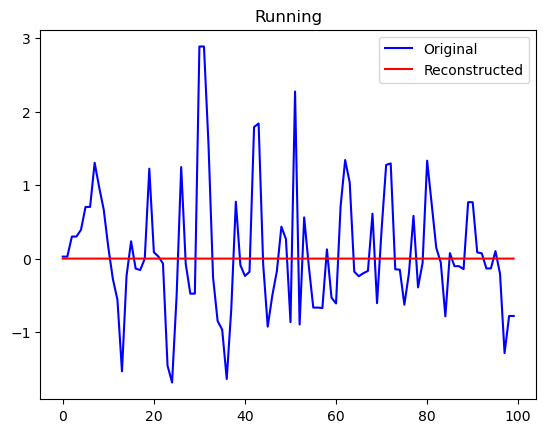

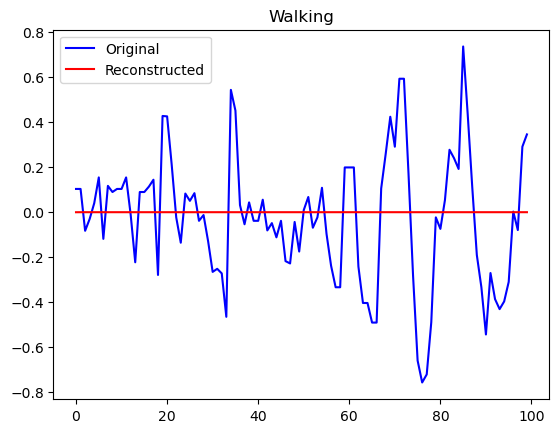

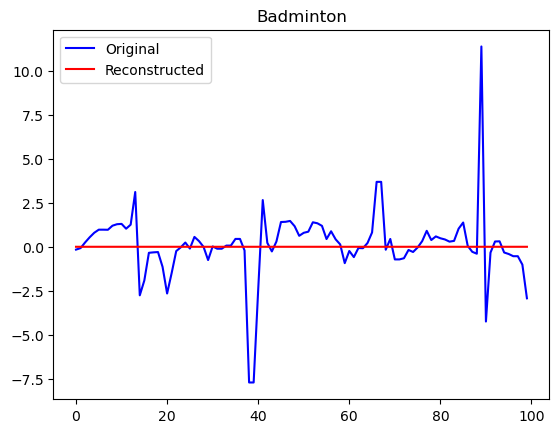

In [16]:
autoencoder_trainer.plot_basicmotions_reconstructions(variable=4)

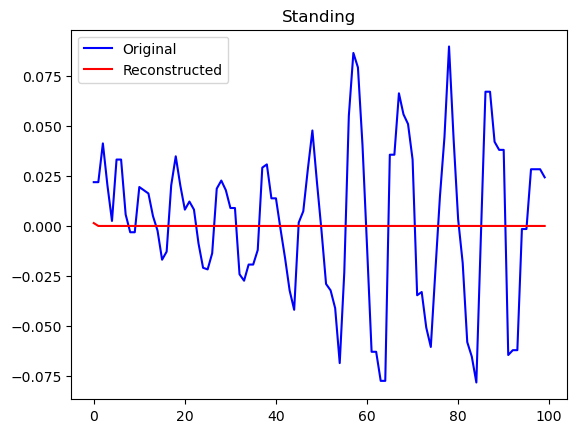

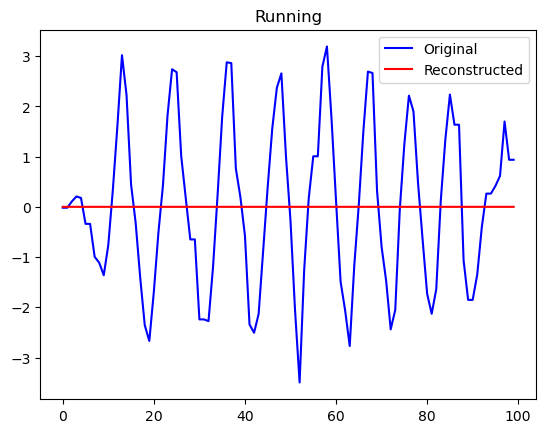

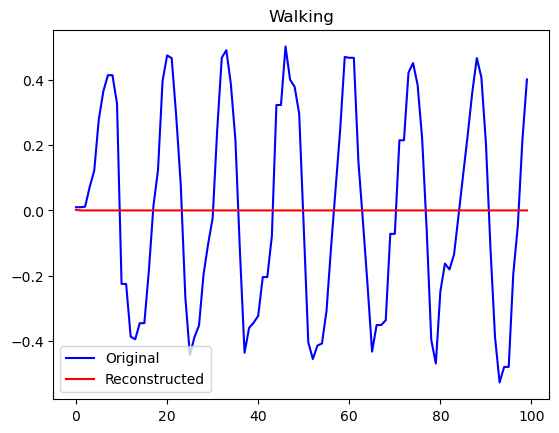

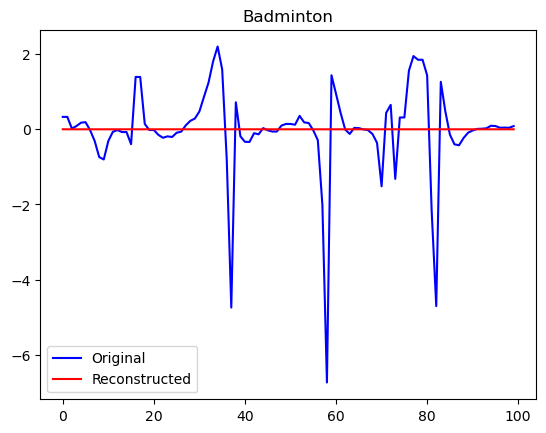

In [17]:
autoencoder_trainer.plot_basicmotions_reconstructions(variable=5)

In [18]:
save = False
if save:
    torch.save(autoencoder_trainer.state_dict(), "/Users/bhaveshkalisetti/Desktop/mmbs/models/basicmotions/new/autoencoder2.dat")